# View result of asteroids data set
Written by Kiyoaki Okudaira<br>
*Kyushu University Hanada Lab / University of Washington / IAU CPS SatHub<br>
(okudaira.kiyoaki.528@s.kyushu-u.ac.jp or kiyoaki@uw.edu)<br>
<br>
View result of the processing of asteroids data set from NASA SENTRY / ESA AEGIS API.<br>
<br>
**History**<br>
coding 2026-02-04 : 1st coding<br>
<br>
This code is written for University of Washington ASTR 302 WINTER 2026 Project NEO.<br>
(c) 2026 Kiyoaki Okudaira - Kyushu University Hanada Lab (SSDL) / University of Washington / IAU CPS SatHub

### Import and initial settings
**PATH settings**

In [1]:
base_PATH = "/Users/kiyoaki/VScode/ASTR302_projectNEO/"
output_PATH = base_PATH + "output"

**Standard libraries**

In [2]:
import pickle
from matplotlib import pyplot as plt

### NASA SENTRY vs ESA AEGIS Comparison Dataset
**Import dataset**

In [3]:
with open(f'{output_PATH}/workspace_NASA_ESA_ip_table.pkl', "rb") as f:
    NASA_ESA_ip_table = pickle.load(f)
NASA_ESA_ip_table

des_chr,des_num,event_id,ip_NASA,ip_ESA
str9,object,str20,object,object
1950DA,29075,1950DA_2880-03-16,0.000377,None
1979XB,None,1979XB_2056-12-12,1.915e-07,2.34e-07
1979XB,None,1979XB_2065-12-16,None,2.72e-09
1979XB,None,1979XB_2086-12-16,1.067e-07,None
1979XB,None,1979XB_2101-12-14,None,3.46e-09
1979XB,None,1979XB_2102-12-16,1.158e-10,None
1979XB,None,1979XB_2113-12-14,5.532e-07,4.94e-07
1991BA,None,1991BA_2026-01-17,None,2.55e-09
1991BA,None,1991BA_2027-01-19,2.107e-09,3.45e-09


**Difference of IP**<br>
If only one of the 2 data set lists an event, the ip_agreements will be `none`

In [4]:
ip_differences = []
ip_agreements = []
for row in NASA_ESA_ip_table:
    if row["ip_NASA"] is None:
        ip_differences.append(-row["ip_ESA"])
        ip_agreements.append(None)
    elif row["ip_ESA"] is None:
        ip_differences.append(row["ip_NASA"])
        ip_agreements.append(None)
    elif row["ip_NASA"] is None and row["ip_ESA"] is None:
        raise ValueError("Invalid event : both IPs are None")
    else:
        ip_differences.append(row["ip_NASA"] - row["ip_ESA"])
        ip_agreements.append(False)
NASA_ESA_ip_table["ip_difference"] = ip_differences
NASA_ESA_ip_table["ip_agreement"] = ip_agreements

NASA_ESA_ip_table

des_chr,des_num,event_id,ip_NASA,ip_ESA,ip_difference,ip_agreement
str9,object,str20,object,object,float64,object
1950DA,29075,1950DA_2880-03-16,0.000377,None,0.000377,None
1979XB,None,1979XB_2056-12-12,1.915e-07,2.34e-07,-4.2500000000000017e-08,False
1979XB,None,1979XB_2065-12-16,None,2.72e-09,-2.72e-09,None
1979XB,None,1979XB_2086-12-16,1.067e-07,None,1.067e-07,None
1979XB,None,1979XB_2101-12-14,None,3.46e-09,-3.46e-09,None
1979XB,None,1979XB_2102-12-16,1.158e-10,None,1.158e-10,None
1979XB,None,1979XB_2113-12-14,5.532e-07,4.94e-07,5.92e-08,False
1991BA,None,1991BA_2026-01-17,None,2.55e-09,-2.55e-09,None
1991BA,None,1991BA_2027-01-19,2.107e-09,3.45e-09,-1.343e-09,False


### Plot result
Plot differences in histogram

Text(0, 0.5, 'Count')

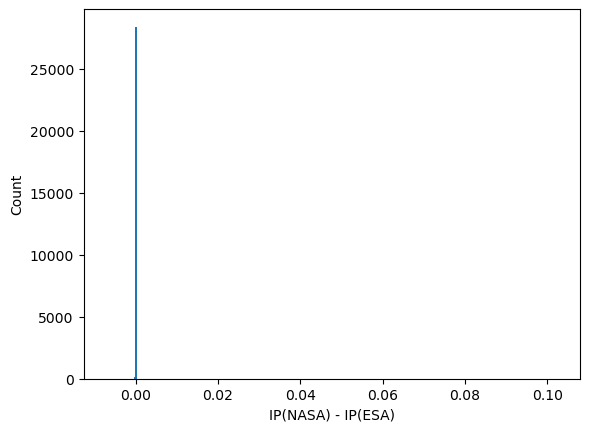

In [5]:
_ = plt.hist(NASA_ESA_ip_table["ip_difference"], bins="auto")
# _ = plt.hist(NASA_ESA_ip_table[(NASA_ESA_ip_table["ip_agreement"] != None)]["ip_difference"], bins="auto")
plt.xlabel("IP(NASA) - IP(ESA)")
plt.ylabel("Count")

Text(0, 0.5, 'Count')

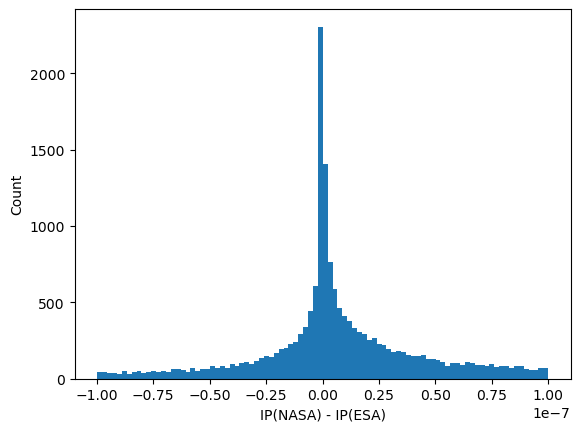

In [6]:
_ = plt.hist(NASA_ESA_ip_table[(abs(NASA_ESA_ip_table["ip_difference"]) < 0.0000001)]["ip_difference"], bins="auto")
# _ = plt.hist(NASA_ESA_ip_table[(abs(NASA_ESA_ip_table["ip_difference"]) < 0.0000001) & (NASA_ESA_ip_table["ip_agreement"] != None)]["ip_difference"], bins="auto")
plt.xlabel("IP(NASA) - IP(ESA)")
plt.ylabel("Count")